In [1]:
!pip install pymcel -Uq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 89.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 52.3 MB/s eta 0:00:00


In [27]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


El problema comienza siempre con dos cuerpos que se atraen gravitacionalmente

In [40]:
# Unidades canonicas
G = 1

m1 = 1
r1_vec_0 = np.array([0,0,0])
v1_vec_0 = np.array([0,0,0])

m2 = 1
r2_vec_0 = np.array([1,0,0])
v2_vec_0 = np.array([0.5,1,0])


La pregunta que se hace la persona es

¿Cuál es la trayectoria que siguen esas dos particulas con esas condiciones iniciales?

El que tiene solución es el problema relativo.

In [41]:
mu = G*(m1+m2)

r_vec_0 = r1_vec_0 - r2_vec_0
v_vec_0 = v1_vec_0 - v2_vec_0

r0 = np.linalg.norm(r_vec_0)
v0 = np.linalg.norm(r_vec_0)

Calculemos las cuadraturas

In [42]:
h_vec = np.cross(r_vec_0,v_vec_0)
# %timeit h = np.linalg.norm(h_vec)
h = np.sqrt(r_vec_0[0]**2+r_vec_0[1]**2+r_vec_0[2]**2)
# %timeit h = np.sqrt(h_vec@h_vec)
# %timeit h = (h_vec@h_vec)**(1/2)
h_vec, h

(array([0., 0., 1.]), np.float64(1.0))

In [43]:
e_vec = np.cross(v_vec_0,h_vec)/mu - r_vec_0/r0
e = np.sqrt(e_vec@e_vec)
e_vec, e

(array([0.5 , 0.25, 0.  ]), np.float64(0.5590169943749475))

Esto nos dice que tenemos una elipse.

`e_vec` apunta al periapsis

In [44]:
epsilon = v0**2/2 - mu/r0
epsilon

np.float64(-1.5)

Verifiquemos la fórmula de $e$

In [45]:
np.sqrt(1 + 2*epsilon*h**2 / mu**2)

np.float64(0.5)

Cantidades geométricas derivadas

In [46]:
p = h**2 / mu
q = p / (1 + e)
Q = p / (1 - e)
p, Q, Q

(np.float64(0.5),
 np.float64(1.1338305413635983),
 np.float64(1.1338305413635983))

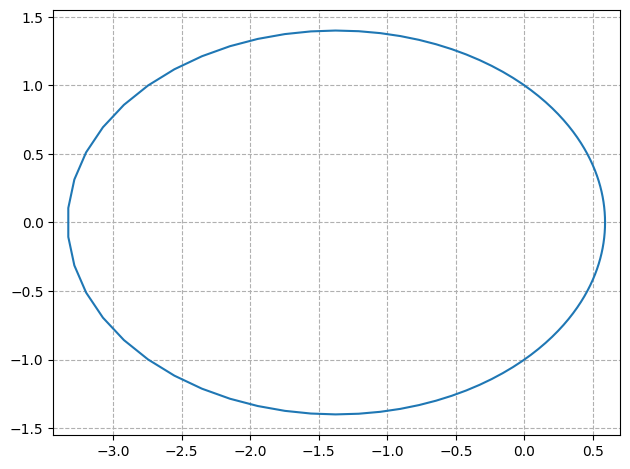

In [47]:
p=1
e=0.7

thetaers = np.linspace(0,2*np.pi,100)
rs = p/(1+e*np.cos(thetaers))

xfs = rs * np.cos(thetaers)
yfs = rs * np.sin(thetaers)

plt.plot(xfs,yfs)
plt.axis('equal')
plt.grid(ls="--")
plt.tight_layout()
plt.show()

In [48]:
m1 =1
m2 = 1
M = m1 + m2

rvecs = np.array([xfs, yfs]).T

r1vecs = m2/M * rvecs
r2vecs = -m1/M * rvecs

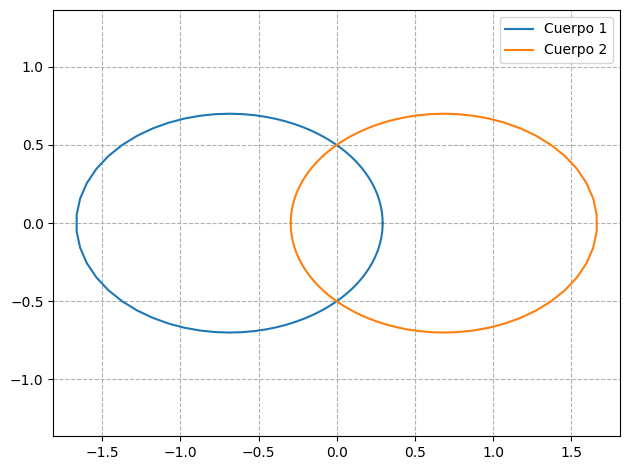

In [49]:
plt.plot(r1vecs[:,0], r1vecs[:,1], label=f'Cuerpo 1')
plt.plot(r2vecs[:,0], r2vecs[:,1], label=f'Cuerpo 2')
plt.axis('equal')
plt.grid(ls="--")
plt.legend()
plt.tight_layout()
plt.show()

Comparar con la teoría de N-Cuerpos

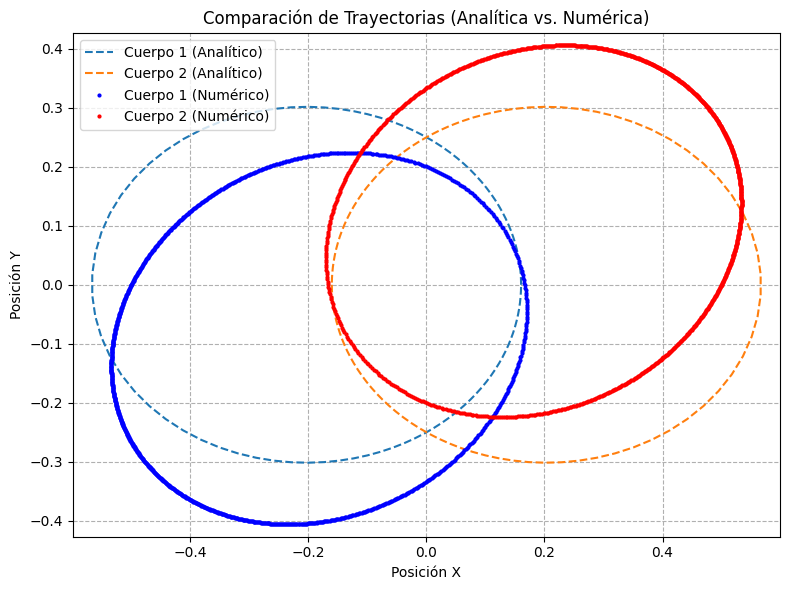

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# Setup for numerical solution (uses global G, m1, m2, r1_vec_0, v1_vec_0, r2_vec_0, v2_vec_0)
sistema = [
    dict(r = r1_vec_0, v = v1_vec_0, m = m1),
    dict(r = r2_vec_0, v = v2_vec_0, m = m2)
]

ts = np.linspace(0,100,1000)
rs_numerical, vs_numerical, rps_numerical, vps_numerical, cuadratura = pc.ncuerpos_solucion(sistema, ts)

# --- Analytical solution calculation (using the correct initial conditions) ---

# Calculate reduced mass parameter
mu_analytical = G * (m1 + m2)

# Relative position and velocity vectors at t=0
r_vec_0_analytical = r1_vec_0 - r2_vec_0
v_vec_0_analytical = v1_vec_0 - v2_vec_0

# Magnitudes
r0_analytical = np.linalg.norm(r_vec_0_analytical)
v0_analytical = np.linalg.norm(v_vec_0_analytical) # Correct calculation for v0

# Angular momentum vector and its magnitude
h_vec_analytical = np.cross(r_vec_0_analytical, v_vec_0_analytical)
h_analytical = np.linalg.norm(h_vec_analytical) # Correct calculation for h

# Eccentricity vector and its magnitude
# Ensure mu_analytical is not zero to prevent division by zero
if mu_analytical == 0:
    e_vec_analytical = np.array([0., 0., 0.]) # Handle this case if needed, though unlikely for gravitational problems
else:
    e_vec_analytical = np.cross(v_vec_0_analytical, h_vec_analytical) / mu_analytical - r_vec_0_analytical / r0_analytical

e_analytical = np.linalg.norm(e_vec_analytical)

# Semilatus rectum (parameter p)
if mu_analytical == 0:
    p_analytical = 0. # Handle this case
else:
    p_analytical = h_analytical**2 / mu_analytical

# Generate angles for plotting
thetaers = np.linspace(0, 2 * np.pi, 100)

# Calculate radial distance for the elliptical orbit
# Ensure the denominator is not zero (only a concern for parabolic orbits, e=1, and specific theta)
denominator = (1 + e_analytical * np.cos(thetaers))
# If e_analytical is < 1 (elliptic), denominator will never be zero.
rs_analytical = p_analytical / denominator

# Convert to Cartesian coordinates (relative orbit)
xfs_analytical = rs_analytical * np.cos(thetaers)
yfs_analytical = rs_analytical * np.sin(thetaers)

# Calculate positions of individual bodies in the lab frame
M_total = m1 + m2 # Total mass
rvecs_relative_analytical = np.array([xfs_analytical, yfs_analytical]).T

r1vecs_analytical = (m2 / M_total) * rvecs_relative_analytical
r2vecs_analytical = -(m1 / M_total) * rvecs_relative_analytical

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(r1vecs_analytical[:, 0], r1vecs_analytical[:, 1], label=f'Cuerpo 1 (Analítico)', linestyle='--')
plt.plot(r2vecs_analytical[:, 0], r2vecs_analytical[:, 1], label=f'Cuerpo 2 (Analítico)', linestyle='--')
plt.plot(rps_numerical[0, :, 0], rps_numerical[0, :, 1], "bo", markersize=2, label=f'Cuerpo 1 (Numérico)')
plt.plot(rps_numerical[1, :, 0], rps_numerical[1, :, 1], "ro", markersize=2, label=f'Cuerpo 2 (Numérico)')
plt.title('Comparación de Trayectorias (Analítica vs. Numérica)')
plt.xlabel('Posición X')
plt.ylabel('Posición Y')
plt.axis('equal')
plt.grid(ls="--")
plt.legend()
plt.tight_layout()
plt.show()

Debemos rotar la cónica para hacer coincidir estas dos orbitas.

$\theta_{\text{er}}, \nu, f:$ Anomalía

Teoría de rotaciones